In [28]:
import gurobipy as gp
from gurobipy import GRB
import numpy as np
import pandas as pd
from scipy.spatial.distance import cdist 
import matplotlib.pyplot as plt 

### Try to model a single agent scheduling and routing problem

Parameters

start_goal:
[[0, 1]]


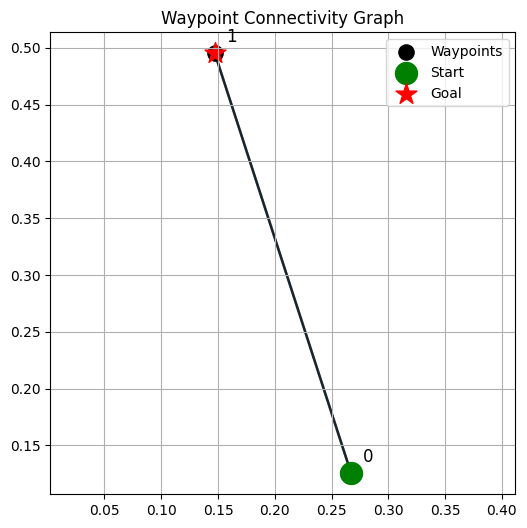

In [29]:
# constants
INF = 1e5

# number of agents
N = 1

# number of waypoints
M = 2

# number of stages
K = M+1

# random matrix
# mask = np.random.uniform(0,1,(M,M))
# mask = mask - np.diag(np.diag(mask))
# mask = 0.5 * (mask + mask.T)
# mask = mask / np.sum(mask, axis=1, keepdims=True)
# mask[mask<=1/(M)] = 0.0 
# mask[mask>1/(M)] = 1.0
# mask = np.maximum(mask, mask.T)
# np.fill_diagonal(mask, 0)
mask = np.array([
    [0, 1], [1, 0]
])
# generate a dummy distance matrix between the waypoints
Y = np.random.uniform(0,1,(M,2))
distMat = cdist(Y, Y, 'euclidean')

# # agent start and end parameters
start_time = np.random.uniform(0,0,(N,))
# start_goal = []
# for n in range(N):
#     s = int(np.random.choice(range(M)))
#     d = int(np.random.choice(range(M)))
#     while d == s:
#         d = int(np.random.choice(range(M)))
#     start_goal.append([s,d])
start_goal = [[0,1]]
print(f"start_goal:\n{start_goal}")

# optimization parameters
c0, c1, c2 = 0.1, 10, 1

# initialize stage sizes
stage_size = []
for k in range(K+1):
    if k == 0 or k == K:
        stage_size.append(1)
    else:
        stage_size.append(M)


# ----- PLOT -----
plt.figure(figsize=(6,6))

# plot waypoints
plt.scatter(Y[:,0], Y[:,1], s=120, color='black', label='Waypoints')

# label nodes
for i in range(M):
    plt.text(Y[i,0]+0.01, Y[i,1]+0.01, f'{i}', fontsize=12)

# plot connectivity arrows
for i in range(M):
    for j in range(M):
        if mask[i,j] == 1:
            dx = Y[j,0] - Y[i,0]
            dy = Y[j,1] - Y[i,1]
            plt.arrow(
                Y[i,0], Y[i,1],
                dx, dy,
                head_width=0.001,
                length_includes_head=True,
                alpha=0.6
            )

# highlight start and goal
plt.scatter(Y[s,0], Y[s,1], s=250, color='green', marker='o', label='Start')
plt.scatter(Y[d,0], Y[d,1], s=250, color='red', marker='*', label='Goal')

plt.title("Waypoint Connectivity Graph")
plt.legend()
plt.grid(True)
plt.axis("equal")
plt.show()

In [30]:
mask, distMat

(array([[0, 1],
        [1, 0]]),
 array([[0.        , 0.38851179],
        [0.38851179, 0.        ]]))

Decision Variables

In [31]:

# inputs to the below block
# num agents
# num waypoints
# start_goal locations
# bounds on schedules
# bounds on inverse speeds
# INF value
# stagewise architecture details
# constants c1, c2 and c3
# network mask
# start times
# disMat
# tolerance array



In [32]:
m = gp.Model("single_agent_MIRS")

# Continuous decision variables
theta = {}
inv_speed = {}
for n in range(N):
    for i in range(M):
        theta[n,i] = m.addVar(vtype=GRB.CONTINUOUS, lb=0.0, ub=1000.0, name=f"T{n}{i}")
    inv_speed[n] = m.addVar(vtype=GRB.CONTINUOUS, lb=10, ub=100, name=f"inv_speed")

# Stagewise decision variables, and corresponding constraints
Z = {}
eta = {}
Xi = {}
prod_constr = {}

for n in range(N):
    s,d = start_goal[n]
    net_mask = mask.copy()
    net_mask[d,:] = 0
    net_mask[d,d] = 1
    distMat_temp = distMat.copy()
    distMat_temp[net_mask == 0.0] = INF
    print(f"n:{n}\ns:{s}\td:{d}\nmask:\n{mask}\nnet_mask:\n{net_mask}\ndistMat:\n{distMat_temp}\n")
    for k in range(K): 
        for i in range(stage_size[k]): 
            for j in range(stage_size[k+1]): 
                Z[n,k,i,j] = m.addVar(vtype=GRB.CONTINUOUS, name=f"Z_{n}{k}{i}{j}") 
                eta[n,k,i,j] = m.addVar(vtype=GRB.BINARY, name=f"eta_{n}{k}{i}{j}") 
                Xi[n,k,i,j] = m.addVar(vtype=GRB.CONTINUOUS, name=f"Xi_{n}{k}{i}{j}") 

                # linearization constraint 
                m.addQConstr( Z[n,k,i,j] == eta[n,k,i,j]*Xi[n,k,i,j], name=f"prod_constr_{n}{k}{i}{j}") 

                # transition cost constraints
                if k == 0:
                    if net_mask[s,j] == 0:
                        expr = INF
                    else:
                        travel_time = distMat_temp[s, j] * inv_speed[n]
                        expr0 = c0 * (theta[n,s] - start_time[n])**2 #(theta[n,s] - start_time[n])
                        expr1 = c1 * (theta[n,j] - theta[n,s] - travel_time)**2 #(theta[n,j] - theta[n,s] - travel_time)
                        expr2 = c2 * travel_time**2 #travel_time
                        expr = expr0 + expr1 + expr2
                elif k > 0 and k < K-1:
                    if net_mask[i,j] == 0:
                        expr = INF
                    else:
                        travel_time = distMat_temp[i, j] * inv_speed[n]
                        expr1 = c1 * (theta[n,j] - theta[n,i] - travel_time)**2 #(theta[n,j] - theta[n,i] - travel_time)
                        expr2 = c2 * travel_time**2 #travel_time 
                        expr = expr1 + expr2 
                elif k == K-1: 
                    if net_mask[i,d] == 0:
                        expr = INF
                    else:
                        travel_time = distMat_temp[i, d] * inv_speed[n]
                        expr1 = c1 * (theta[n,d] - theta[n,i] - travel_time)**2 #(theta[n,d] - theta[n,i] - travel_time)
                        expr2 = c2 * travel_time**2 #travel_time
                        expr = expr1 + expr2
                
                m.addConstr(Xi[n,k,i,j] == expr, name=f"cost_constr_{n}{k}{i}{j}") 

            # binary association constraints 
            m.addConstr(gp.quicksum(eta[n,k,i,j] for j in range(stage_size[k+1])) == 1, name=f"sum_eta_{n}{k}{i}") 

    for n1 in range(n+1,N):
        for j in range(M):
            m.addConstr((theta[n,j]-theta[n1,j])*(theta[n,j]-theta[n1,j]) >= 9.0, name=f"collision_constr_{n}{n1}{j}")

m.Params.NonConvex = 2 
m.update() 

print("Number of quadratic constraints:", m.NumQConstrs) 
print("Number of linear constraints:", m.NumConstrs) 


n:0
s:0	d:1
mask:
[[0 1]
 [1 0]]
net_mask:
[[0 1]
 [0 1]]
distMat:
[[1.00000000e+05 3.88511792e-01]
 [1.00000000e+05 0.00000000e+00]]

Set parameter NonConvex to value 2
Number of quadratic constraints: 13
Number of linear constraints: 8


Define objective function

In [33]:
def returnD(Z):
    V = [None]*N
    for n in range(N):
        U = [None]*K
        for k in range(K):
            # final stage to destination
            if k == 0:
                U[K-1-k] = {}
                j = 0
                for i in range(stage_size[K-1-k]):
                    U[K-1-k][i] = Z[n,K-1-k,i,j]
            elif k > 0 and k < K-1:
                U[K-1-k] = {}
                for i in range(stage_size[K-1-k]):
                    expr = []
                    for j in range(stage_size[K-k]):
                        expr.append((Z[n,K-1-k,i,j] + U[K-k][j]))
                    U[K-1-k][i] = sum(expr)
            elif k == K-1:
                U[K-1-k] = {}
                expr = []
                i = 0
                for j in range(stage_size[K-k]):
                    expr.append((Z[n,K-1-k,i,j] + U[K-k][j]))
                U[K-1-k] = sum(expr)
        V[n] = U[0]

    return sum(V)
    

In [34]:
m.setParam("NonConvex", 2) 

m.setParam("TimeLimit", 600) 
m.setParam("MIPGap", 0.05) 

m.setParam("MIPFocus", 2)
m.setParam("Heuristics", 0.8)

m.setParam("Cuts", 2)
m.setParam("OBBT", 2)

m.setParam("NumericFocus", 2)
m.setParam("Presolve", 2) 

obj = returnD(Z) 
m.setObjective(obj, GRB.MINIMIZE) 

m.optimize() 


Set parameter NonConvex to value 2
Set parameter TimeLimit to value 600
Set parameter MIPGap to value 0.05
Set parameter MIPFocus to value 2
Set parameter Heuristics to value 0.8
Set parameter Cuts to value 2
Set parameter OBBT to value 2
Set parameter NumericFocus to value 2
Set parameter Presolve to value 2
Gurobi Optimizer version 12.0.3 build v12.0.3rc0 (mac64[arm] - Darwin 24.6.0 24G419)

CPU model: Apple M2
Thread count: 8 physical cores, 8 logical processors, using up to 8 threads

Non-default parameters:
TimeLimit  600
MIPGap  0.05
Heuristics  0.8
MIPFocus  2
OBBT  2
Cuts  2
NonConvex  2
NumericFocus  2
Presolve  2

Optimize a model with 8 rows, 27 columns and 11 nonzeros
Model fingerprint: 0x251e7a40
Model has 13 quadratic constraints
Variable types: 19 continuous, 8 integer (8 binary)
Coefficient statistics:
  Matrix range     [1e+00, 1e+00]
  QMatrix range    [1e+00, 2e+01]
  QLMatrix range   [1e+00, 1e+00]
  Objective range  [1e+00, 2e+00]
  Bounds range     [1e+00, 1e+03]


Stagewise cost

In [35]:
# print start and goal locations

# Distance matrix
print(f"\n --- Distance matrix --- ")
print(f"{distMat}")

# Print scalar stagewise variables
for n in range(N):
    print(f"agent:{n}")
    print(f"\n\t--- start-goal locations ---")
    s,d = start_goal[n]
    print(f"\tStart:{s}\t{theta[n,s].X:.3f}\tGoal:{d}\t{theta[n,d].X:.3f}:")

    print("\n\t--- Continuous variables theta ---")
    for i in range(M):
        print(f"\ttheta[{n},{i}] = {theta[n,i].X}") 

    print("\n\t--- Continuous variable inv_speed ---") 
    print(f"\tinv_speed[{n}] = {inv_speed[n].X}") 

    print("\n\t--- Stagewise variables ---") 
    for k in range(K): 
        for i in range(stage_size[k]):
            for j in range(stage_size[k+1]):
                print(f"\tZ[{n},{k},{i},{j}] = {Z[n,k,i,j].X:.3e}, \t eta[{n},{k},{i},{j}] = {eta[n,k,i,j].X},\t Xi[{n},{k},{i},{j}] = {Xi[n,k,i,j].X:.3e}")




 --- Distance matrix --- 
[[0.         0.38851179]
 [0.38851179 0.        ]]
agent:0

	--- start-goal locations ---
	Start:0	0.000	Goal:1	3.885:

	--- Continuous variables theta ---
	theta[0,0] = 0.00012826823205428677
	theta[0,1] = 3.8852461875361057

	--- Continuous variable inv_speed ---
	inv_speed[0] = 10.0

	--- Stagewise variables ---
	Z[0,0,0,0] = 0.000e+00, 	 eta[0,0,0,0] = 0.0,	 Xi[0,0,0,0] = 1.000e+05
	Z[0,0,0,1] = 1.509e+01, 	 eta[0,0,0,1] = 1.0,	 Xi[0,0,0,1] = 1.509e+01
	Z[0,1,0,0] = 0.000e+00, 	 eta[0,1,0,0] = 0.0,	 Xi[0,1,0,0] = 1.000e+05
	Z[0,1,0,1] = 1.509e+01, 	 eta[0,1,0,1] = 1.0,	 Xi[0,1,0,1] = 1.509e+01
	Z[0,1,1,0] = 0.000e+00, 	 eta[0,1,1,0] = 0.0,	 Xi[0,1,1,0] = 1.000e+05
	Z[0,1,1,1] = 0.000e+00, 	 eta[0,1,1,1] = 1.0,	 Xi[0,1,1,1] = 0.000e+00
	Z[0,2,0,0] = 1.509e+01, 	 eta[0,2,0,0] = 1.0,	 Xi[0,2,0,0] = 1.509e+01
	Z[0,2,1,0] = 0.000e+00, 	 eta[0,2,1,0] = 1.0,	 Xi[0,2,1,0] = 0.000e+00
